In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\user\OneDrive\Desktop\hiring-bias-fairness\data\raw\resume_ai_screening.csv"
)

df.head()

,gender,age,education_level,experience_years,screening_score,shortlisted
0,Male,35,Masters,1,72.473130,0
1,Female,32,Bachelors,15,55.004084,0
2,Male,36,Masters,19,60.156004,0
3,Male,44,Bachelors,6,75.846397,0
4,Male,39,High School,1,43.297540,1


In [5]:
import matplotlib.pyplot as plt

In [6]:
df.shape

(2000, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            2000 non-null   object 
 1   age               2000 non-null   int64  
 2   education_level   2000 non-null   object 
 3   experience_years  2000 non-null   int64  
 4   screening_score   2000 non-null   float64
 5   shortlisted       2000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 93.9+ KB


In [8]:
df['shortlisted'].value_counts()

shortlisted
0    1195
1     805
Name: count, dtype: int64

#shortlisting by gender

In [14]:
df.groupby('gender')['shortlisted'].mean()

gender
Female    0.420732
Male      0.384843
Name: shortlisted, dtype: float64

#Compare experience by gender

In [17]:
df.groupby('gender')['experience_years'].mean()

gender
Female    9.501016
Male      9.719488
Name: experience_years, dtype: float64

#Plot shortlisting rate by gender

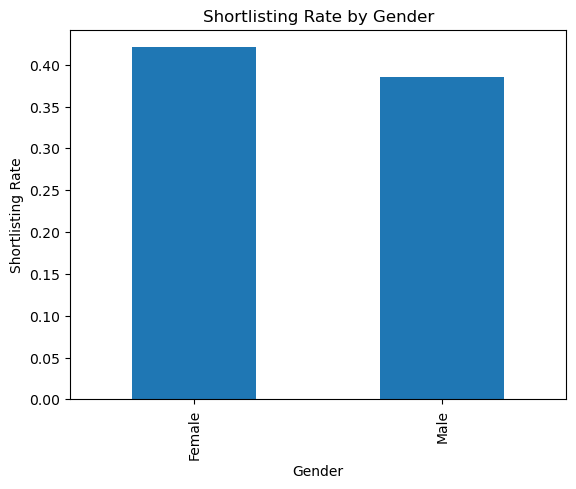

In [20]:
df.groupby('gender')['shortlisted'].mean().plot(
    kind='bar',
    title='Shortlisting Rate by Gender',
    ylabel='Shortlisting Rate',
    xlabel='Gender'
)
plt.show()

#Plot experience distribution by gender

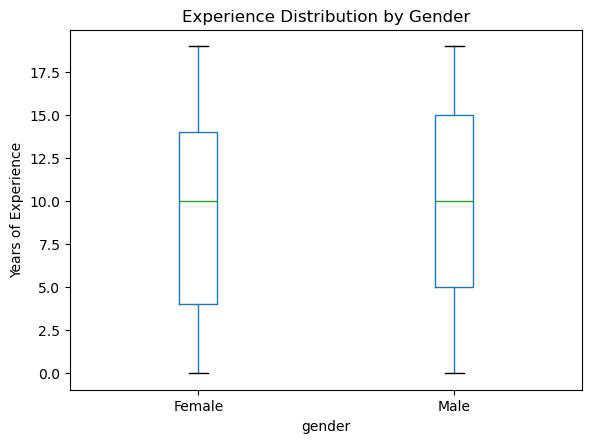

In [23]:
df.boxplot(
    column='experience_years',
    by='gender',
    grid=False
)
plt.title('Experience Distribution by Gender')
plt.suptitle('')
plt.ylabel('Years of Experience')
plt.show()

In [25]:
df.groupby('gender')['experience_years'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
gender,,,,
Female,9.501016,10.0,0,19
Male,9.719488,10.0,0,19


#Shortlisting rate by education

In [28]:
df.groupby('education_level')['shortlisted'].mean()

education_level
Bachelors      0.401768
High School    0.396419
Masters        0.396728
PhD            0.460784
Name: shortlisted, dtype: float64

#Education distribution by gender

In [31]:
pd.crosstab(df['education_level'], df['gender'], normalize='columns')

gender,Female,Male
education_level,,
Bachelors,0.507114,0.510827
High School,0.201220,0.189961
Masters,0.232724,0.255906
PhD,0.058943,0.043307


In [33]:
pd.crosstab(df['education_level'], df['gender'])

gender,Female,Male
education_level,,
Bachelors,499,519
High School,198,193
Masters,229,260
PhD,58,44


In [35]:
pd.crosstab(df['education_level'], df['gender'], normalize='index')

gender,Female,Male
education_level,,
Bachelors,0.490177,0.509823
High School,0.506394,0.493606
Masters,0.468303,0.531697
PhD,0.568627,0.431373


#average screening score by gender

In [38]:
df.groupby('gender')['screening_score'].mean()

gender
Female    70.366802
Male      70.041268
Name: screening_score, dtype: float64

#Screening score by shortlisting outcome

In [41]:
df.groupby('shortlisted')['screening_score'].mean()

shortlisted
0    70.311189
1    70.038498
Name: screening_score, dtype: float64

In [43]:
# Target variable
y = df['shortlisted']

# Feature variables
X = df.drop(columns='shortlisted')

In [45]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
X_encoded.columns

Index(['age', 'experience_years', 'screening_score', 'gender_Male',
       'education_level_High School', 'education_level_Masters',
       'education_level_PhD'],
      dtype='object')

In [51]:
X_encoded.head()

,age,experience_years,screening_score,gender_Male,education_level_High School,education_level_Masters,education_level_PhD
0,35,1,72.473130,True,False,True,False
1,32,15,55.004084,False,False,False,False
2,36,19,60.156004,True,False,True,False
3,44,6,75.846397,True,False,False,False
4,39,1,43.297540,True,True,False,False


In [53]:
X.shape, X_encoded.shape

((2000, 5), (2000, 7))

In [55]:
X_encoded = X_encoded.astype(int)

In [57]:
X_encoded.head()

,age,experience_years,screening_score,gender_Male,education_level_High School,education_level_Masters,education_level_PhD
0,35,1,72,1,0,1,0
1,32,15,55,0,0,0,0
2,36,19,60,1,0,1,0
3,44,6,75,1,0,0,0
4,39,1,43,1,1,0,0


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [61]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [63]:
y_pred = model.predict(X_test)

In [65]:
accuracy_score(y_test, y_pred)

0.61

In [67]:
confusion_matrix(y_test, y_pred)

array([[243,   1],
       [155,   1]], dtype=int64)

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       244
           1       0.50      0.01      0.01       156

    accuracy                           0.61       400
   macro avg       0.56      0.50      0.38       400
weighted avg       0.57      0.61      0.47       400



In [71]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [73]:
y_pred_balanced = model_balanced.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_score(y_test, y_pred_balanced)

0.53

In [77]:
confusion_matrix(y_test, y_pred_balanced)

array([[127, 117],
       [ 71,  85]], dtype=int64)

In [79]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.64      0.52      0.57       244
           1       0.42      0.54      0.47       156

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.52       400
weighted avg       0.56      0.53      0.54       400



In [81]:
import pandas as pd

coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model_balanced.coef_[0]
}).sort_values("coef", ascending=False)

coef_table

,feature,coef
6,education_level_PhD,0.229024
0,age,0.004714
2,screening_score,-0.004497
1,experience_years,-0.008418
5,education_level_Masters,-0.053061
4,education_level_High School,-0.110775
3,gender_Male,-0.118860


In [83]:
model_balanced.intercept_

array([0.31439731])

In [87]:
import numpy as np
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table

,feature,coef,odds_ratio
6,education_level_PhD,0.229024,1.257372
0,age,0.004714,1.004725
2,screening_score,-0.004497,0.995513
1,experience_years,-0.008418,0.991618
5,education_level_Masters,-0.053061,0.948322
4,education_level_High School,-0.110775,0.895140
3,gender_Male,-0.118860,0.887932


In [91]:
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred_balanced
results["gender"] = X_test["gender_Male"].map({True: "Male", False: "Female"})
results.head()

,age,experience_years,screening_score,gender_Male,education_level_High School,education_level_Masters,education_level_PhD,actual,predicted,gender
1860,30,4,73.400597,False,True,False,False,1,0,Female
353,34,8,75.141953,False,False,False,True,0,1,Female
1333,37,4,73.697408,False,False,False,True,1,1,Female
905,29,5,53.568597,False,False,False,False,1,1,Female
1289,33,4,80.418506,True,False,False,False,0,0,Male


In [93]:
results.groupby("gender")["predicted"].mean()

gender
Female    0.753695
Male      0.248731
Name: predicted, dtype: float64

In [97]:
from sklearn.metrics import recall_score

results.groupby("gender").apply(
    lambda x: recall_score(x["actual"], x["predicted"]))

C:\Users\user\AppData\Local\Temp\ipykernel_13112\1899701687.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results.groupby("gender").apply(


gender
Female    0.764706
Male      0.281690
dtype: float64

In [99]:
results["false_negative"] = (
    (results["actual"] == 1) & (results["predicted"] == 0))
results.groupby("gender")["false_negative"].mean()

gender
Female    0.098522
Male      0.258883
Name: false_negative, dtype: float64

In [101]:
dashboard_summary = results.groupby("gender").agg(
    shortlisted_rate=("predicted", "mean"),
    recall=("actual", lambda x: (results.loc[x.index, "predicted"] & x).sum() / x.sum()),
    false_negative_rate=("false_negative", "mean")
).reset_index()
dashboard_summary

,gender,shortlisted_rate,recall,false_negative_rate
0,Female,0.753695,0.764706,0.098522
1,Male,0.248731,0.281690,0.258883
